<a href="https://colab.research.google.com/github/SimonAndSmart/Spintorch_packages/blob/main/Interative_SpinTorch(draft).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# SpinTorch (colab version)

In [1]:
import matplotlib as mpl
print('matplotlib: {}'.format(mpl.__version__))

matplotlib: 3.2.2


In [1]:
! pip install --upgrade matplotlib

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.4/9.4 MB 54.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 965.4/965.4 KB 42.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 300.0/300.0 KB 15.9 MB/s eta 0:00:00
  Attempting uninstall: matplotlib
    Found existing installation: matplotlib 3.2.2
    Uninstalling matplotlib-3.2.2:
      Successfully uninstalled matplotlib-3.2.2


**restart the code executor**

In [2]:
import matplotlib as mpl
print('matplotlib: {}'.format(mpl.__version__))

matplotlib: 3.6.3


In [1]:
! git clone https://github.com/SimonAndSmart/Spintorch_packages.git

fatal: destination path 'Spintorch_packages' already exists and is not an empty directory.


## test region 1

In [12]:
%cd /content/Spintorch_packages
! git pull

/content/Spintorch_packages
Already up to date.


In [13]:
%cd /content/Spintorch_packages
import torch
import os
import spintorch
import numpy as np
from spintorch.utils import tic, toc, stat_cuda
from spintorch.plot import wave_integrated, wave_snapshot

import warnings
warnings.filterwarnings("ignore", message=".*Casting complex values to real.*")

/content/Spintorch_packages


In [14]:
#@title ## 1. System Physical Parameters
dx = 50e-9          # discretization (m)
dy = 50e-9          # discretization (m)  
dz = 20e-9          # discretization (m)

#@markdown size x/y  (cells)
nx = 120         #@param {type:"number"}  # size x    (cells)
ny = 80         #@param {type:"number"}  # size y    (cells)

#@markdown  saturation magnetization (A/m)
Ms = 140e3    #@param {type:"number"} # saturation magnetization (A/m)
#@markdown  bias field (T)
B0 = 60e-3    #@param {type:"number"} # bias field (T)
#@markdown excitation field amplitude (T)
Bt = 1e-3    #@param {type:"number"} # excitation field amplitude (T)

'''Geometry, sources, probes, model definitions'''
#@markdown 

#@markdown  Module Geometry
geometry_type = 3 #Permanent magnets #@param ["1 # Flip magnets", "2 #Permanent magnets (training multiplier)", "3 #Permanent magnets"] {type:"raw"}

if geometry_type == 1 :
  Ms_CoPt = 723e3 # saturation magnetization of the nanomagnets (A/m)
  r0, dr, dm, z_off = 15, 4, 2, 10  # starting pos, period, magnet size, z distance
  rx, ry = int((nx-2*r0)/dr), int((ny-2*r0)/dr+1)
  rho = torch.zeros((rx, ry))  # Design parameter array
  geom = spintorch.WaveGeometryArray(rho, (nx, ny), (dx, dy, dz), Ms, B0, r0, dr, dm, z_off, rx, ry, Ms_CoPt)
elif geometry_type == 2 :
  B1 = 50e-3      # training field multiplier (T)
  geom = spintorch.WaveGeometryFreeForm((nx, ny), (dx, dy, dz), B0, B1, Ms)
else:
  geom = spintorch.WaveGeometryMs((nx, ny), (dx, dy, dz), Ms, B0)
######
src = spintorch.WaveLineSource(10, 0, 10, ny-1, dim=2)
probes = []
#@markdown number of probes
Np = 2 #@param {type:"integer"}
for p in range(Np):
    probes.append(spintorch.WaveIntensityProbeDisk(nx-15, int(ny*(p+1)/(Np+1)), 2))


In [19]:
#@title ## 2. Training Parameters
#@markdown Learning rate
learn_rate = 0.01 #@param {type:"number"}
#@markdown number of training epoch
epoch_max = 20  #@param {type:"number"}
#@markdown timestep (s)
dt = 10e-12   #@param {type:"number"} # timestep (s)
#@markdown number of timesteps for wave propagation
timesteps = 1440+500 #@param {type:"number"} # 

'''Define model'''
model = spintorch.MMSolver(geom, dt, [src], probes)

if torch.cuda.is_available():
  dev = torch.device('cuda')  # 'cuda' or 'cpu'
else:
  dev = torch.device('cpu')
print('Running on', dev)
model.to(dev)   # sending model to GPU/CPU

'''Define optimizer and lossfunction'''
optimizer = torch.optim.Adam(model.parameters(), lr=learn_rate)

def my_loss(pred, labels):
  loss=[]
  for i in range(len(labels)):
    target_value = pred[i][int(labels[i])]
    target_loss = pred[i:i+1].sum(dim=1)/target_value-1
    loss.append(((target_loss.sum()/target_loss.size()[0]).log10()).view(1))
  loss=torch.cat(loss)
  #loss = torch.clamp(loss, min=1e-5, max=1e5)
  print("DEBUG:",loss)
  return torch.mean(loss)

Running on cuda


In [16]:
#@title ## 3. Define Training Data
from torch.utils.data import TensorDataset , DataLoader

f1 = 5e9      # source frequency (Hz)
time_duration = 100 # `number of time step for each information`
# `how the frequency changes`
f_list_1 = [1.0,1.0] + list(np.zeros(3))+[1.0,1.0] + list(np.zeros(3))+[1.0,1.0] + list(np.zeros(3))+[1.0,1.0] + list(np.zeros(3)) 
f_list_2 = [1.0,1.0] + list(np.zeros(2))+[1.0,1.0] + list(np.zeros(2))+[1.0,1.0] + list(np.zeros(2))+[1.0,1.0] + list(np.zeros(2))+[1.0,1.0] + list(np.zeros(2)) 

f1_change_list=[f_list_1,f_list_2]

time_duration = time_duration
t_list=[]    ### changes here! ### 
for i in range(timesteps//time_duration):
  t_list.append(torch.arange(i*time_duration*dt, (i+1)*time_duration*dt, dt, device=dev).unsqueeze(0).unsqueeze(2)) # time vector
if timesteps%time_duration != 0:
  t_list.append(torch.arange((timesteps//time_duration)*time_duration*dt, timesteps*dt, dt, device=dev).unsqueeze(0).unsqueeze(2))

t = torch.arange(0, timesteps*dt, dt, device=dev).unsqueeze(0).unsqueeze(2) # time vector

inputs_list,outputs_list=[],[]

for cases in range(len(f1_change_list)):
  INPUTS = torch.tensor([]).to(dev)
  for i in range(len(t_list)):
    INPUTS =  torch.cat((INPUTS,Bt*torch.sin(2*np.pi*f1_change_list[cases][i]*f1*t_list[i])),1).to(dev)
  OUTPUTS = torch.tensor([cases]).to(dev) # desired output

  inputs_list.append(INPUTS)
  outputs_list.append(OUTPUTS)

# read the size of the tensor in list and create a big enough tensor to contain all
INPUTS_list = torch.Tensor(len(inputs_list), *(inputs_list[0].shape[1:])).to(dev)  
OUTPUTS_list = torch.Tensor(len(outputs_list),*(outputs_list[0].shape[1:])).to(dev)
# convert a list of tensors into one big tensor for creating data loader
torch.cat(inputs_list, out=INPUTS_list)
torch.cat(outputs_list, out=OUTPUTS_list)

train_tensor=TensorDataset(INPUTS_list,OUTPUTS_list)
batch_size = len(inputs_list) # can be smaller if later using a larger data sets.
train_loader = DataLoader(train_tensor, batch_size=batch_size, shuffle=True, num_workers=1)

In [17]:
#@title ## 4. Define Dirictiry and Load Model
'''Directories'''
#@markdown base dirictiry of this model 
basedir = "focus_Ms/" #@param {type:"string"}
plotdir = 'plots/' + basedir
deleate_image = True #@param {type:"boolean"}
deleate_model = True #@param {type:"boolean"}
if not os.path.isdir(plotdir):
    os.makedirs(plotdir)
elif deleate_image == True:
  %rm -rf $plotdir
savedir = 'models/' + basedir
if not os.path.isdir(savedir):
    os.makedirs(savedir) 
elif deleate_model == True:
  %rm -rf $savedir
'''Load checkpoint'''
#@markdown  select previous checkpoint (-1 = don't use checkpoint)
epoch = -1 #@param {type:"integer"}
epoch_init = epoch
if epoch_init>=0:
    checkpoint = torch.load(savedir + 'model_e%d.pt' % (epoch_init))
    epoch = checkpoint['epoch']
    loss_iter = checkpoint['loss_iter']
    model.load_state_dict(checkpoint['model_state_dict'])
    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
else:
    loss_iter = []

## test region 2

In [134]:
u.shape

torch.Size([1, 1948, 2])

In [79]:
OUTPUTS.shape

torch.Size([2])

In [101]:
u.shape

torch.Size([1, 1948, 2])

In [105]:
torch.cat([u,u]).shape

torch.Size([2, 1948, 2])

In [97]:
INPUTS.shape

torch.Size([2, 1948, 1])

In [8]:
u.shape

torch.Size([2, 1948, 2])

## test region 3

In [201]:
def my_loss(pred, labels):
  loss=[]
  for i in range(len(labels)):
    target_value = pred[i][int(labels[i])]
    target_loss = pred[i:i+1].sum(dim=1)/target_value-1
    loss.append(((target_loss.sum()/target_loss.size()[0]).log10()).view(1))
  loss=torch.cat(loss)
  #loss = torch.clamp(loss, min=1e-5, max=1e5)
  print("DEBUG:",loss)
  return torch.mean(loss)

In [ ]:
def custom_loss(pred, labels):
  for epoch in range(len(pred)):
    
    above_loss = torch.log10(pred - threshold + 1).mean()
    return loss

In [60]:
u[0][int(OUTPUTS[0])]

tensor(9.8565e+10, device='cuda:0', grad_fn=<SelectBackward0>)

In [172]:
in_data[0]

tensor([2.6357e+11, 2.6359e+11])

In [181]:
in_data=torch.tensor([[2.6357e+11, 1.6359e+11],[1e+10, 7.3715997e+11]])
out_data=torch.tensor([0,1])

my_loss(in_data,out_data)

DEBUG: tensor([-0.2071, -1.8676])


tensor(-1.1409)

In [189]:
len(u)

2

In [186]:
u[0][0,]

tensor(1.4053e+11, device='cuda:0', grad_fn=<SelectBackward0>)

In [195]:
u[i:i+1][0,].size()[0]

2

In [190]:
range(1,1+u.size()[0])

range(1, 3)

In [18]:
#@title ## 5. Start Training
%cd
%cd /content/Spintorch_packages
tic()
model.retain_history = True
for epoch in range(epoch_init+1, epoch_max):
                      ### Changes here! ###
    #for batch, data in enumerate(train_loader, 0):
      INPUTS  = INPUTS_list
      OUTPUTS = OUTPUTS_list
      optimizer.zero_grad()
      u = model(INPUTS).sum(dim=1)
      for i in range(len(u)):
        spintorch.plot.plot_output(u[i:i+1][0,],i,epoch, plotdir)
      loss = my_loss(u,OUTPUTS)
      loss_iter.append(loss.item())  # store loss values
      spintorch.plot.plot_loss(loss_iter, plotdir)
      stat_cuda('after forward')
      loss.backward()
      optimizer.step()
      stat_cuda('after backward')
      print("epoch finished: %d -- Loss: %.6f" % (epoch, loss))
      toc()   

      '''Save model checkpoint'''
      torch.save({
                'epoch': epoch,
                'loss_iter': loss_iter,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict()
                }, savedir + 'model_e%d.pt' % (epoch))
    
      '''Plot spin-wave propagation'''
      if model.retain_history:
        with torch.no_grad():
            spintorch.plot.geometry(model, epoch=epoch, plotdir=plotdir)
            mz = torch.stack(model.m_history, 1)[0,:,2,]-model.m0[0,2,].unsqueeze(0).cpu()
            wave_snapshot(model, mz[timesteps-1], (plotdir+'snapshot_time%d_epoch%d.png' % (timesteps,epoch)),r"$m_z$")
            wave_snapshot(model, mz[int(timesteps/2)-1], (plotdir+'snapshot_time%d_epoch%d.png' % (int(timesteps/2),epoch)),r"$m_z$")
            wave_integrated(model, mz, (plotdir+'integrated_epoch%d.png' % (epoch)))

/root
/content/Spintorch_packages
DEBUG: [tensor([0.0354], device='cuda:0', grad_fn=<ViewBackward0>), tensor([-0.0355], device='cuda:0', grad_fn=<ViewBackward0>)]
DEBUG: tensor(-2.5202e-05, device='cuda:0', grad_fn=<MeanBackward0>)
GPU memory usage after forward:
allocated: 20M (max 25M), cached: 26M (max 26M)
GPU memory usage after backward:
allocated: 10M (max 42M), cached: 46M (max 46M)
epoch finished: 0 -- Loss: -0.000025
Elapsed time 67.13 s, (dt = 67.13 s)
DEBUG: [tensor([0.1830], device='cuda:0', grad_fn=<ViewBackward0>), tensor([-0.3719], device='cuda:0', grad_fn=<ViewBackward0>)]
DEBUG: tensor(-0.0945, device='cuda:0', grad_fn=<MeanBackward0>)
GPU memory usage after forward:
allocated: 20M (max 42M), cached: 46M (max 46M)
GPU memory usage after backward:
allocated: 10M (max 42M), cached: 46M (max 46M)
epoch finished: 1 -- Loss: -0.094456
Elapsed time 142.64 s, (dt = 75.51 s)
DEBUG: [tensor([0.4433], device='cuda:0', grad_fn=<ViewBackward0>), tensor([-0.9096], device='cuda:0', 

KeyboardInterrupt: ignored

/root
/content/Spintorch_packages/plots/focus_Ms


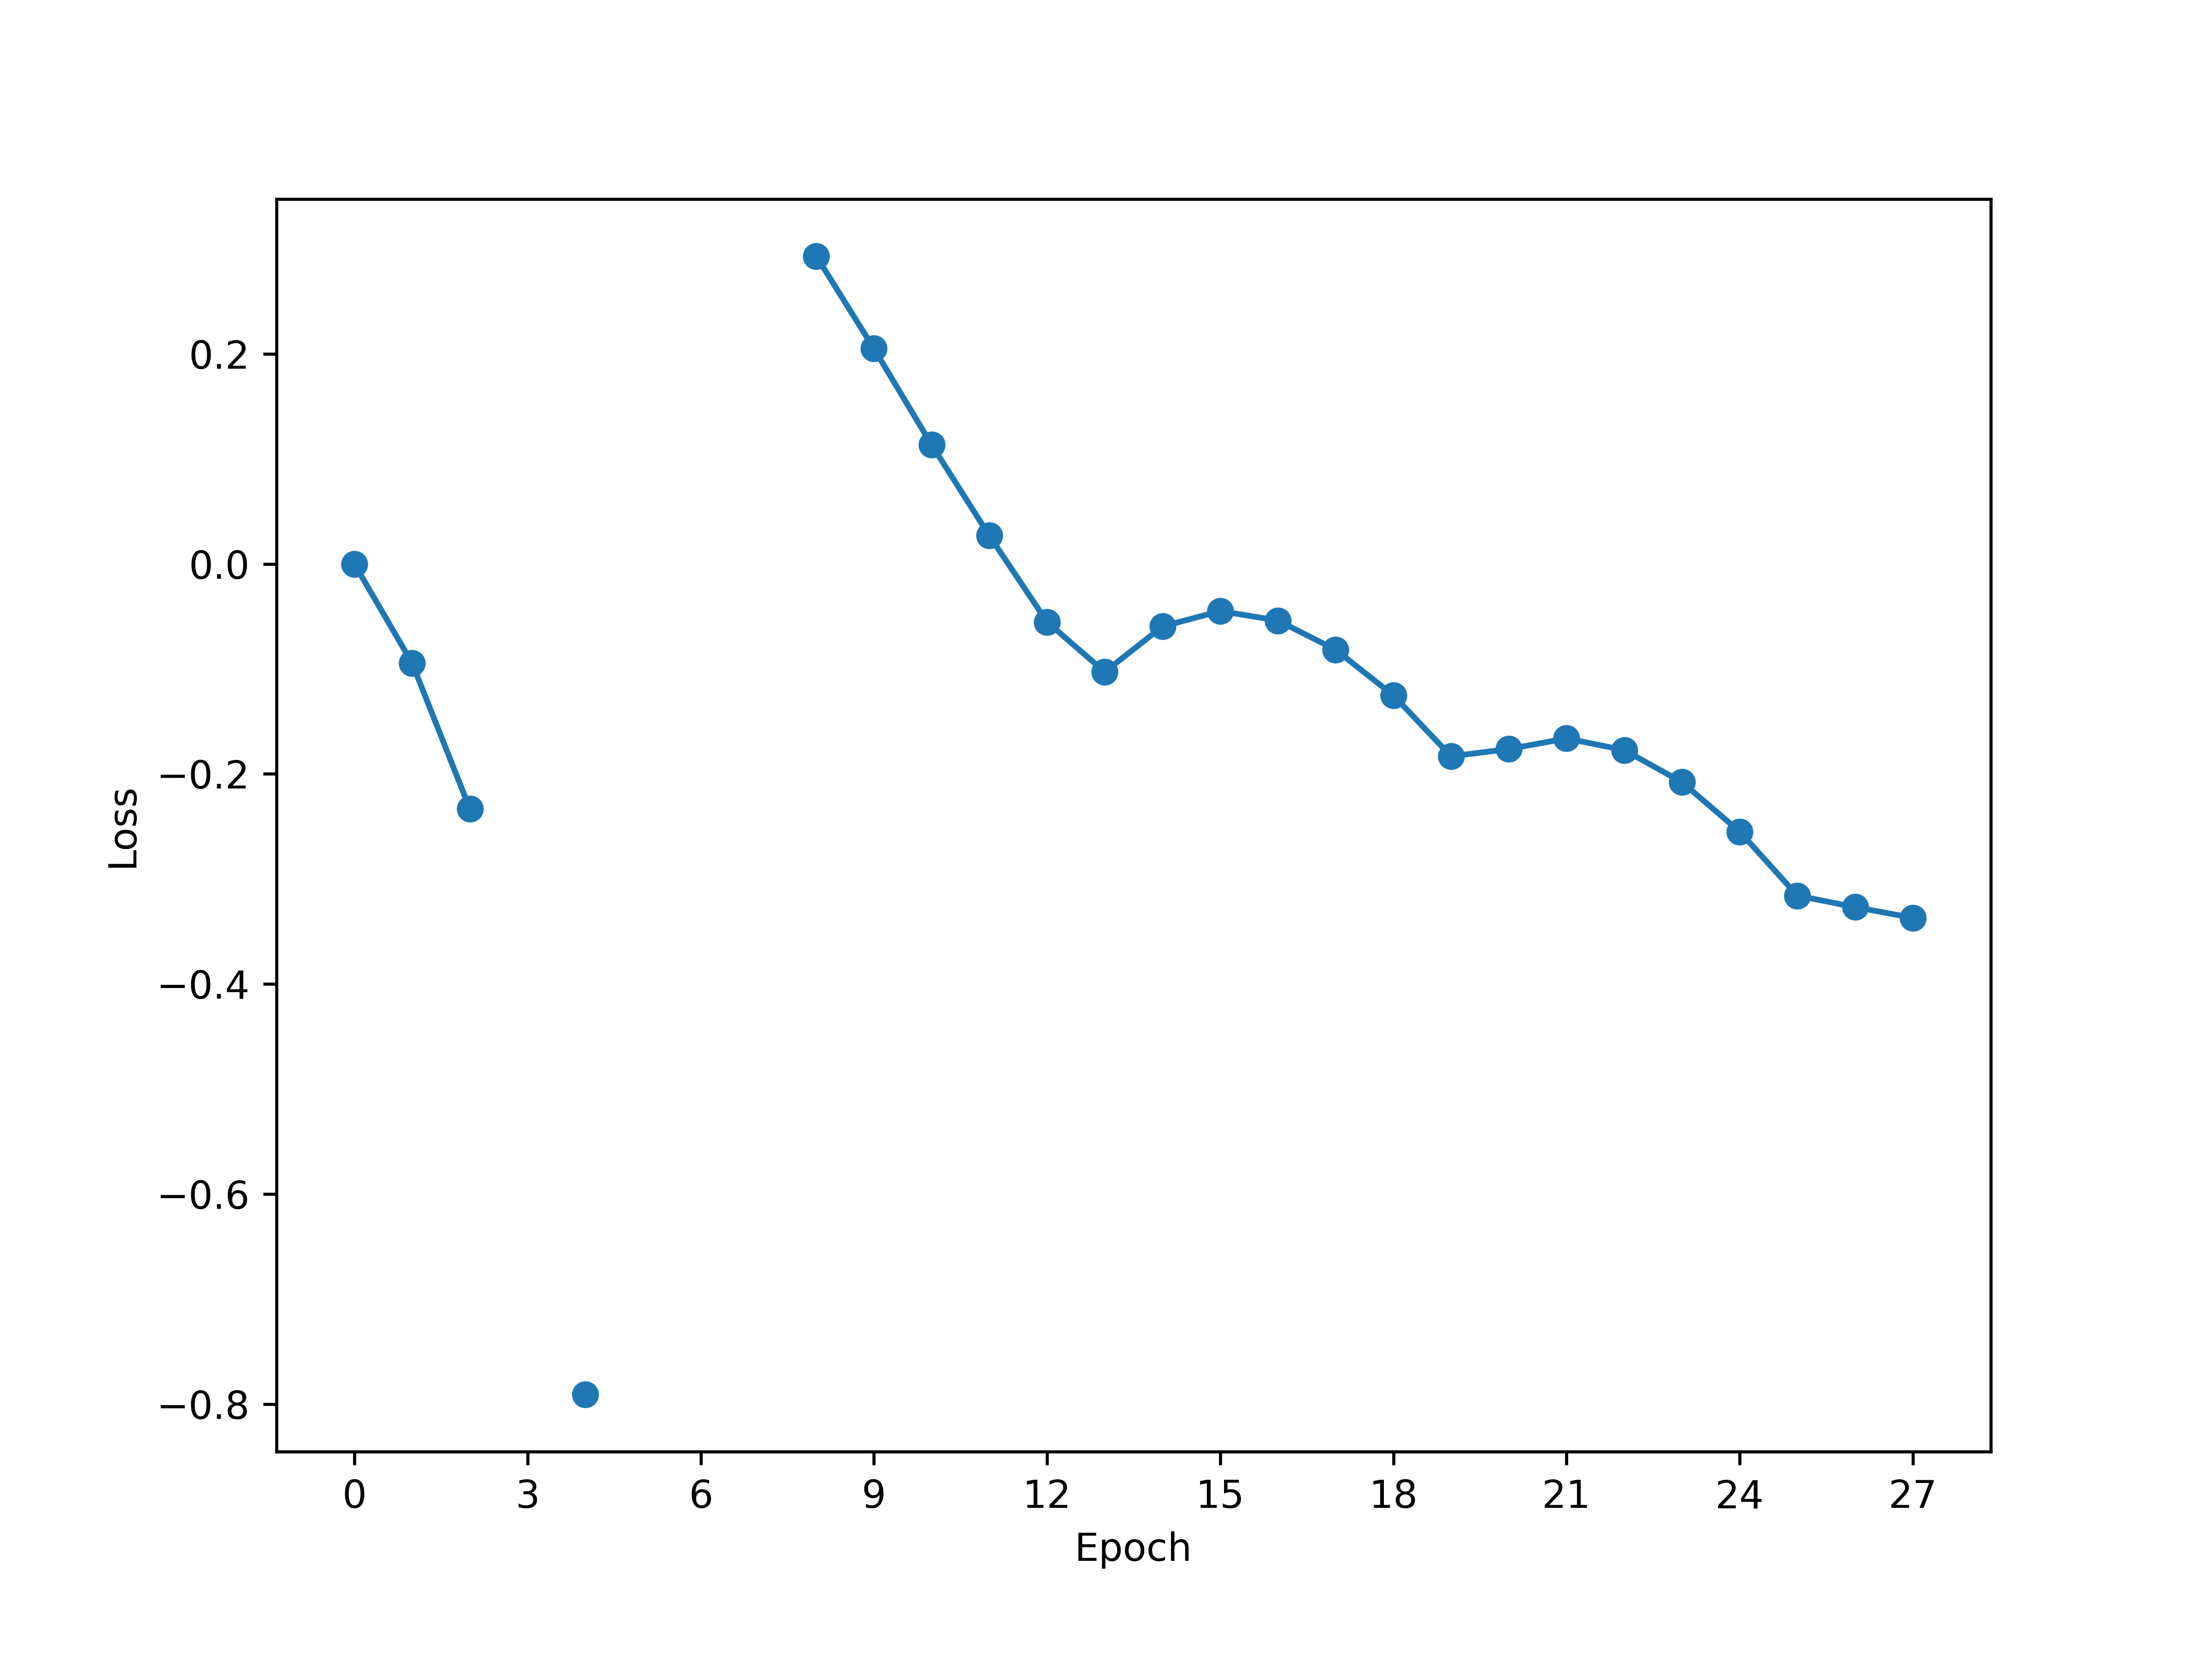

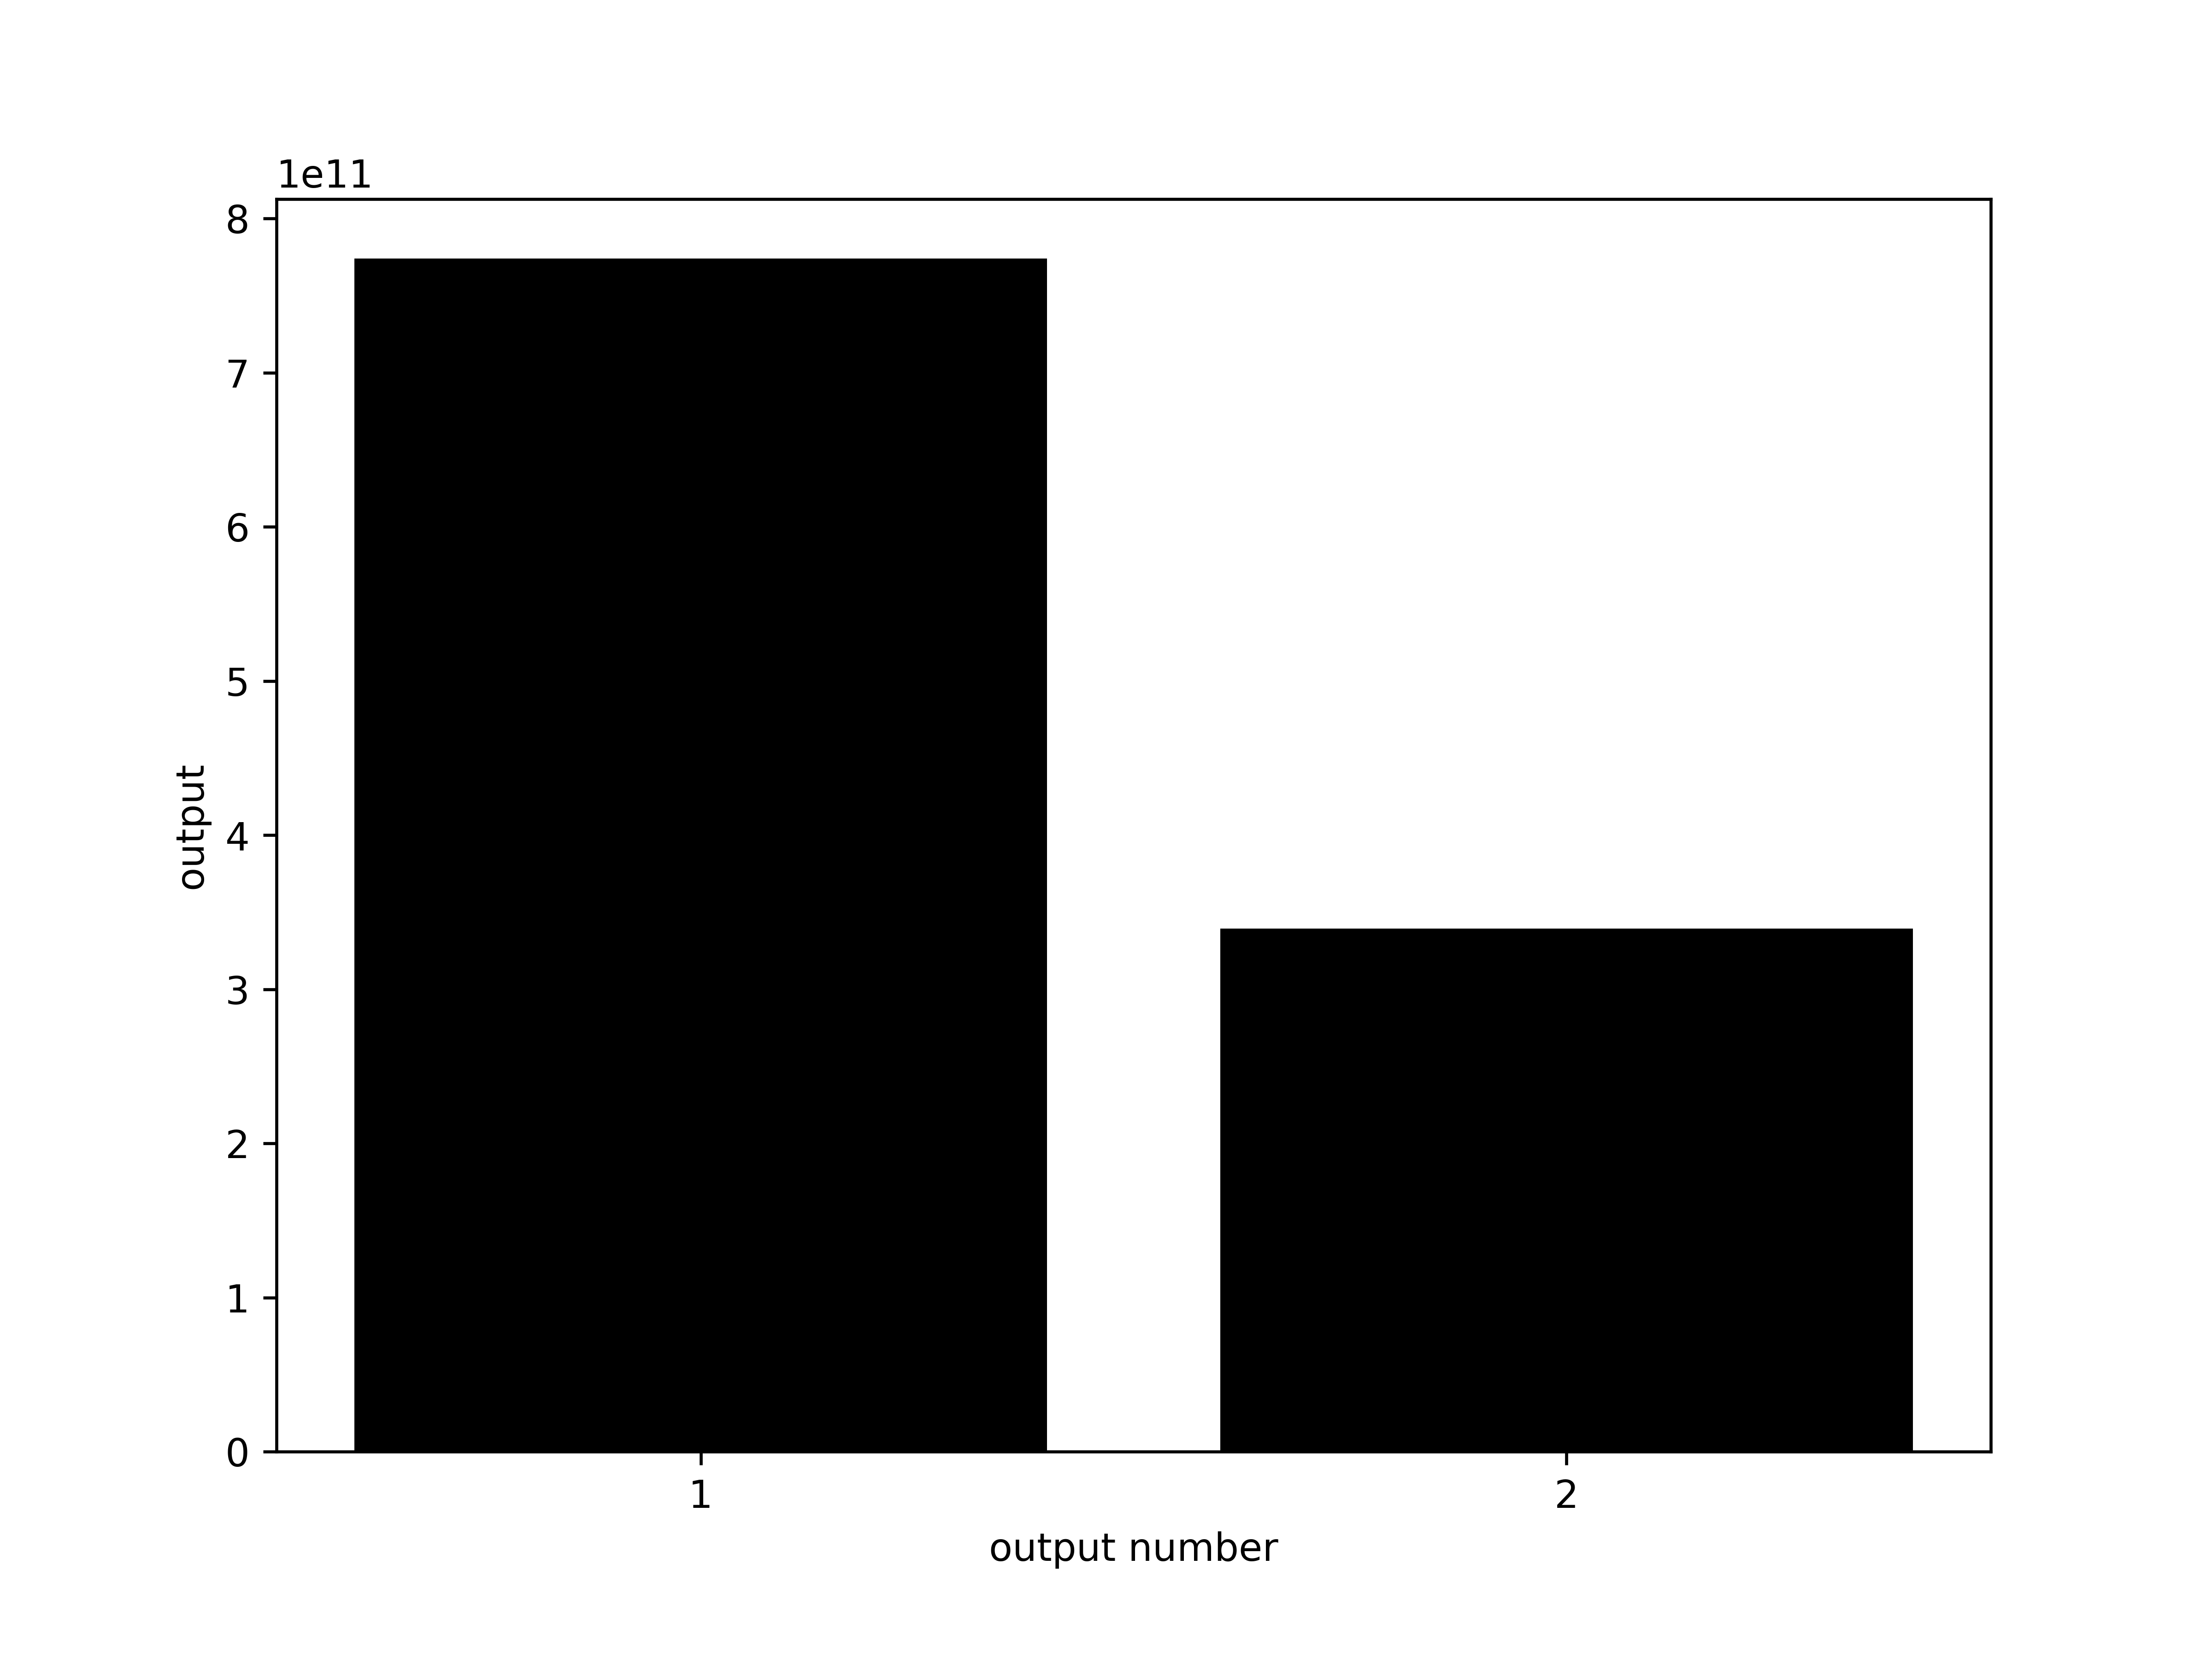

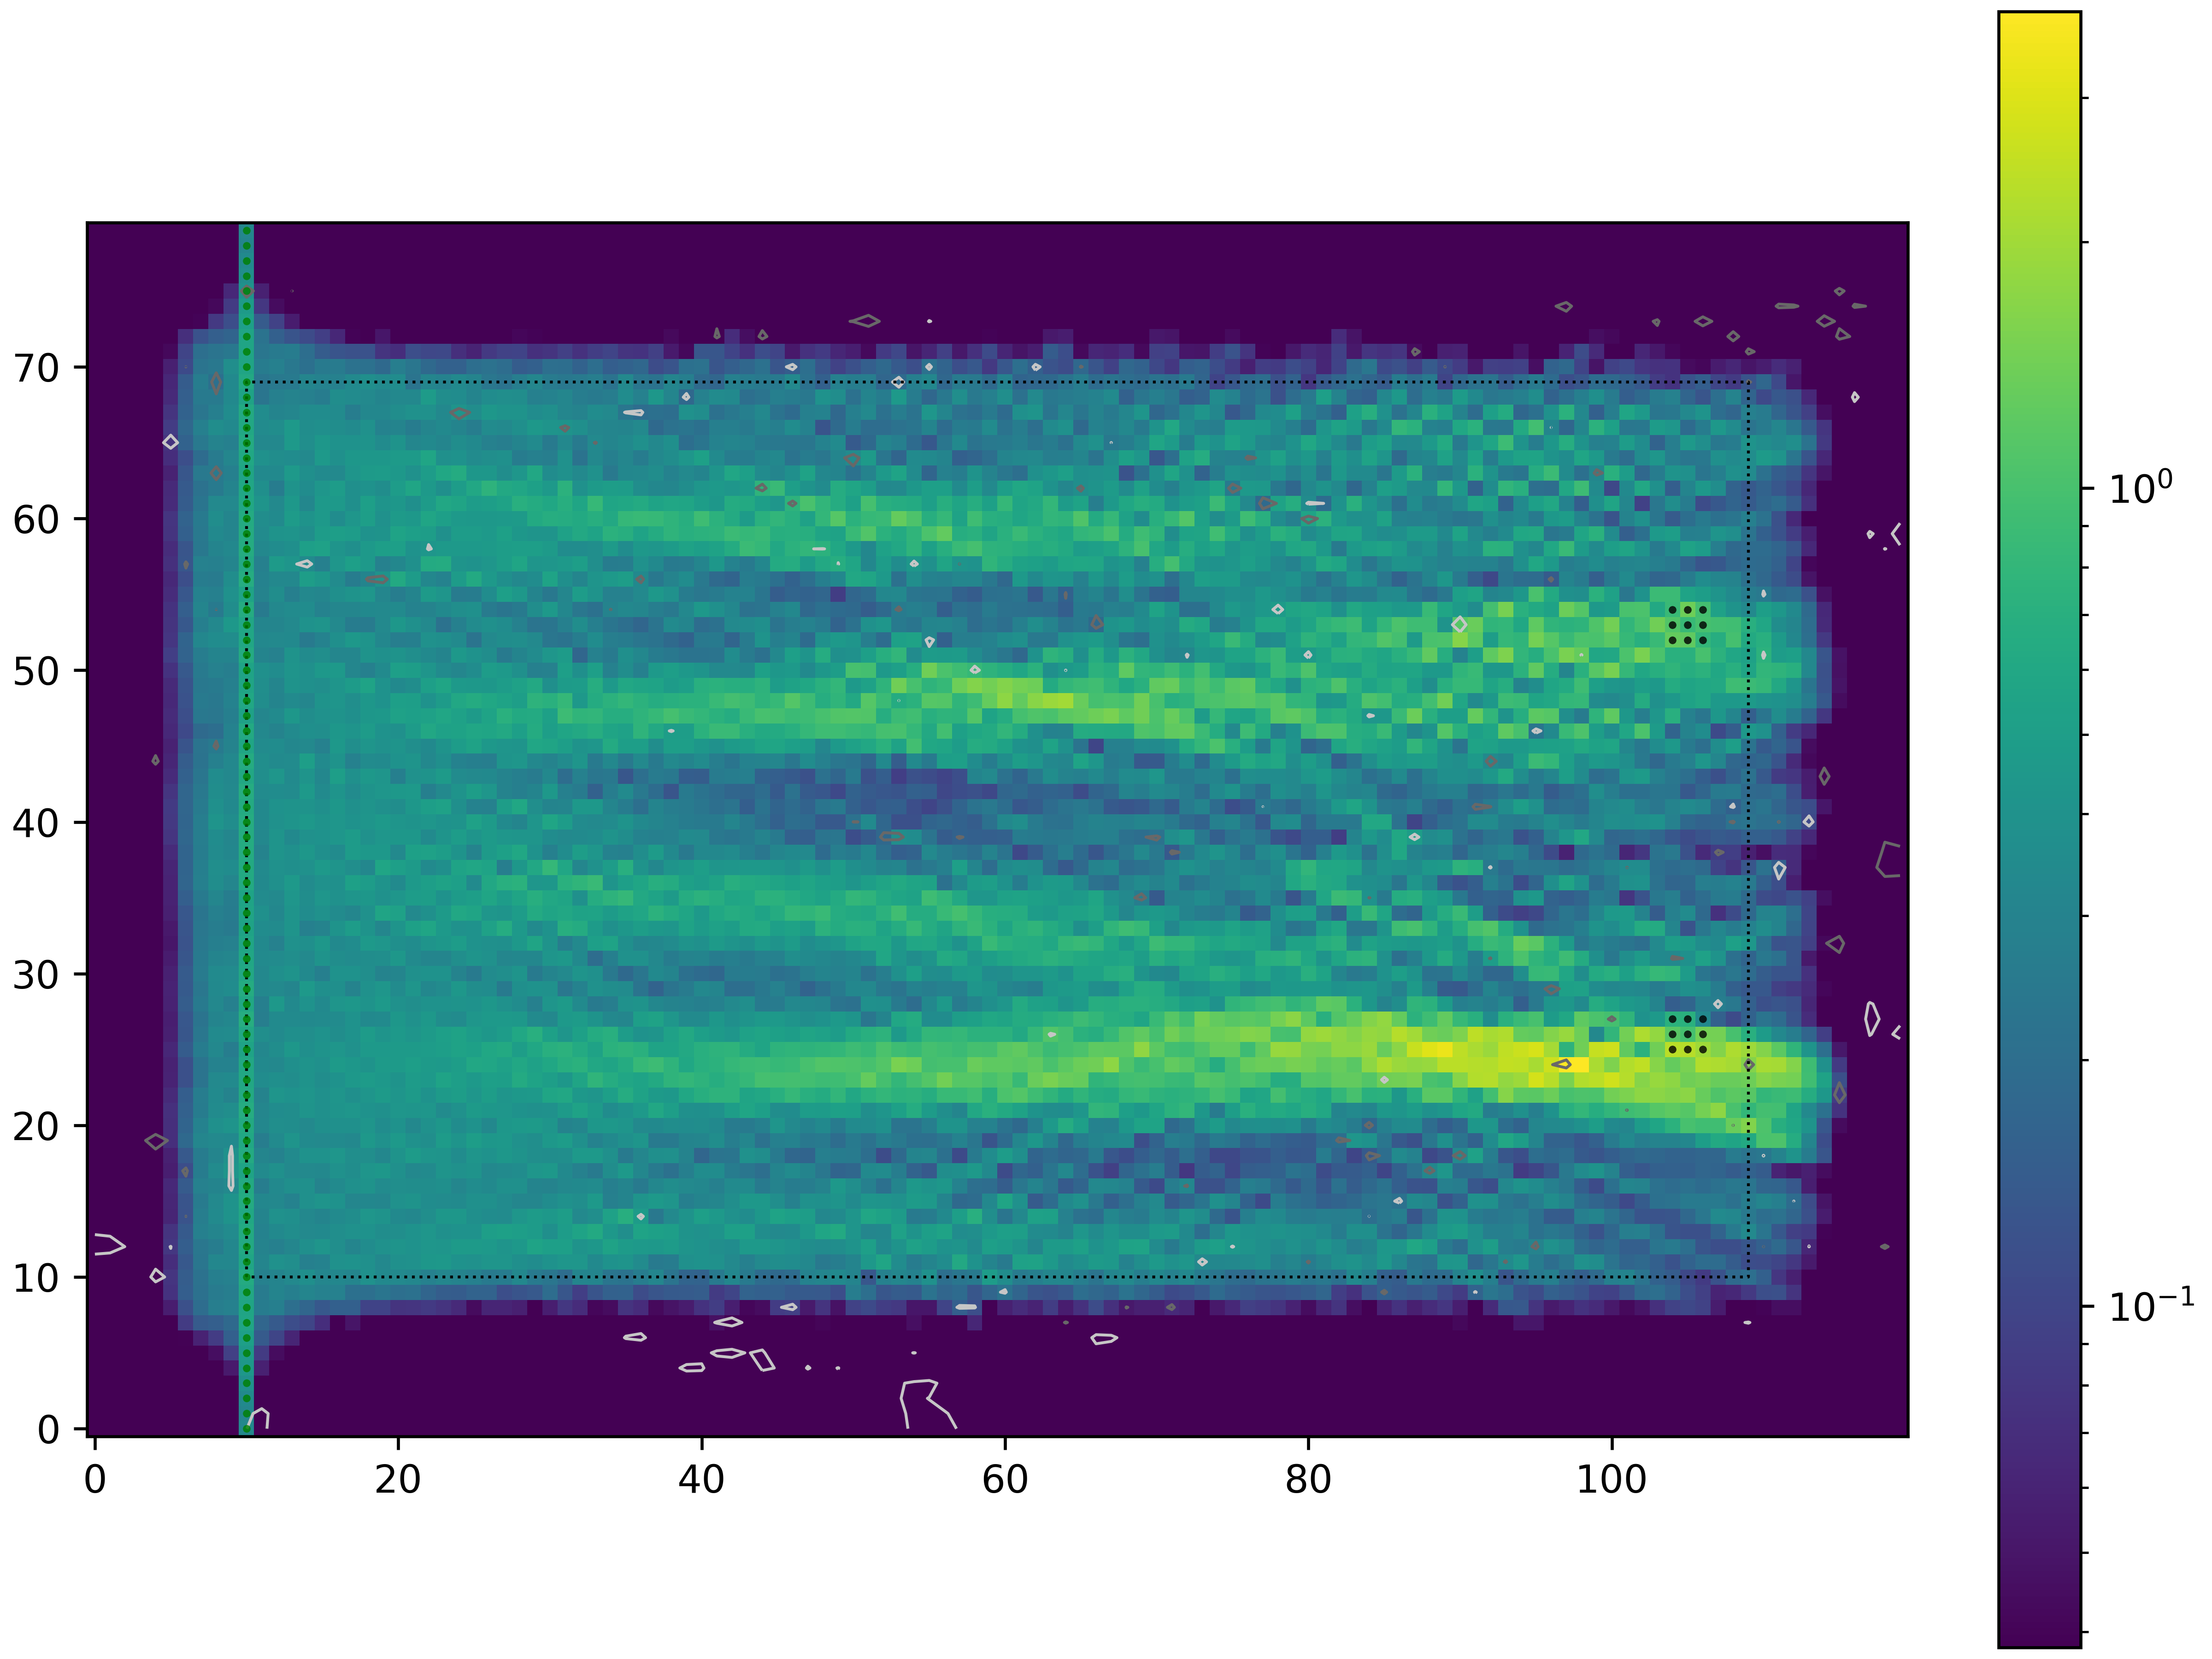

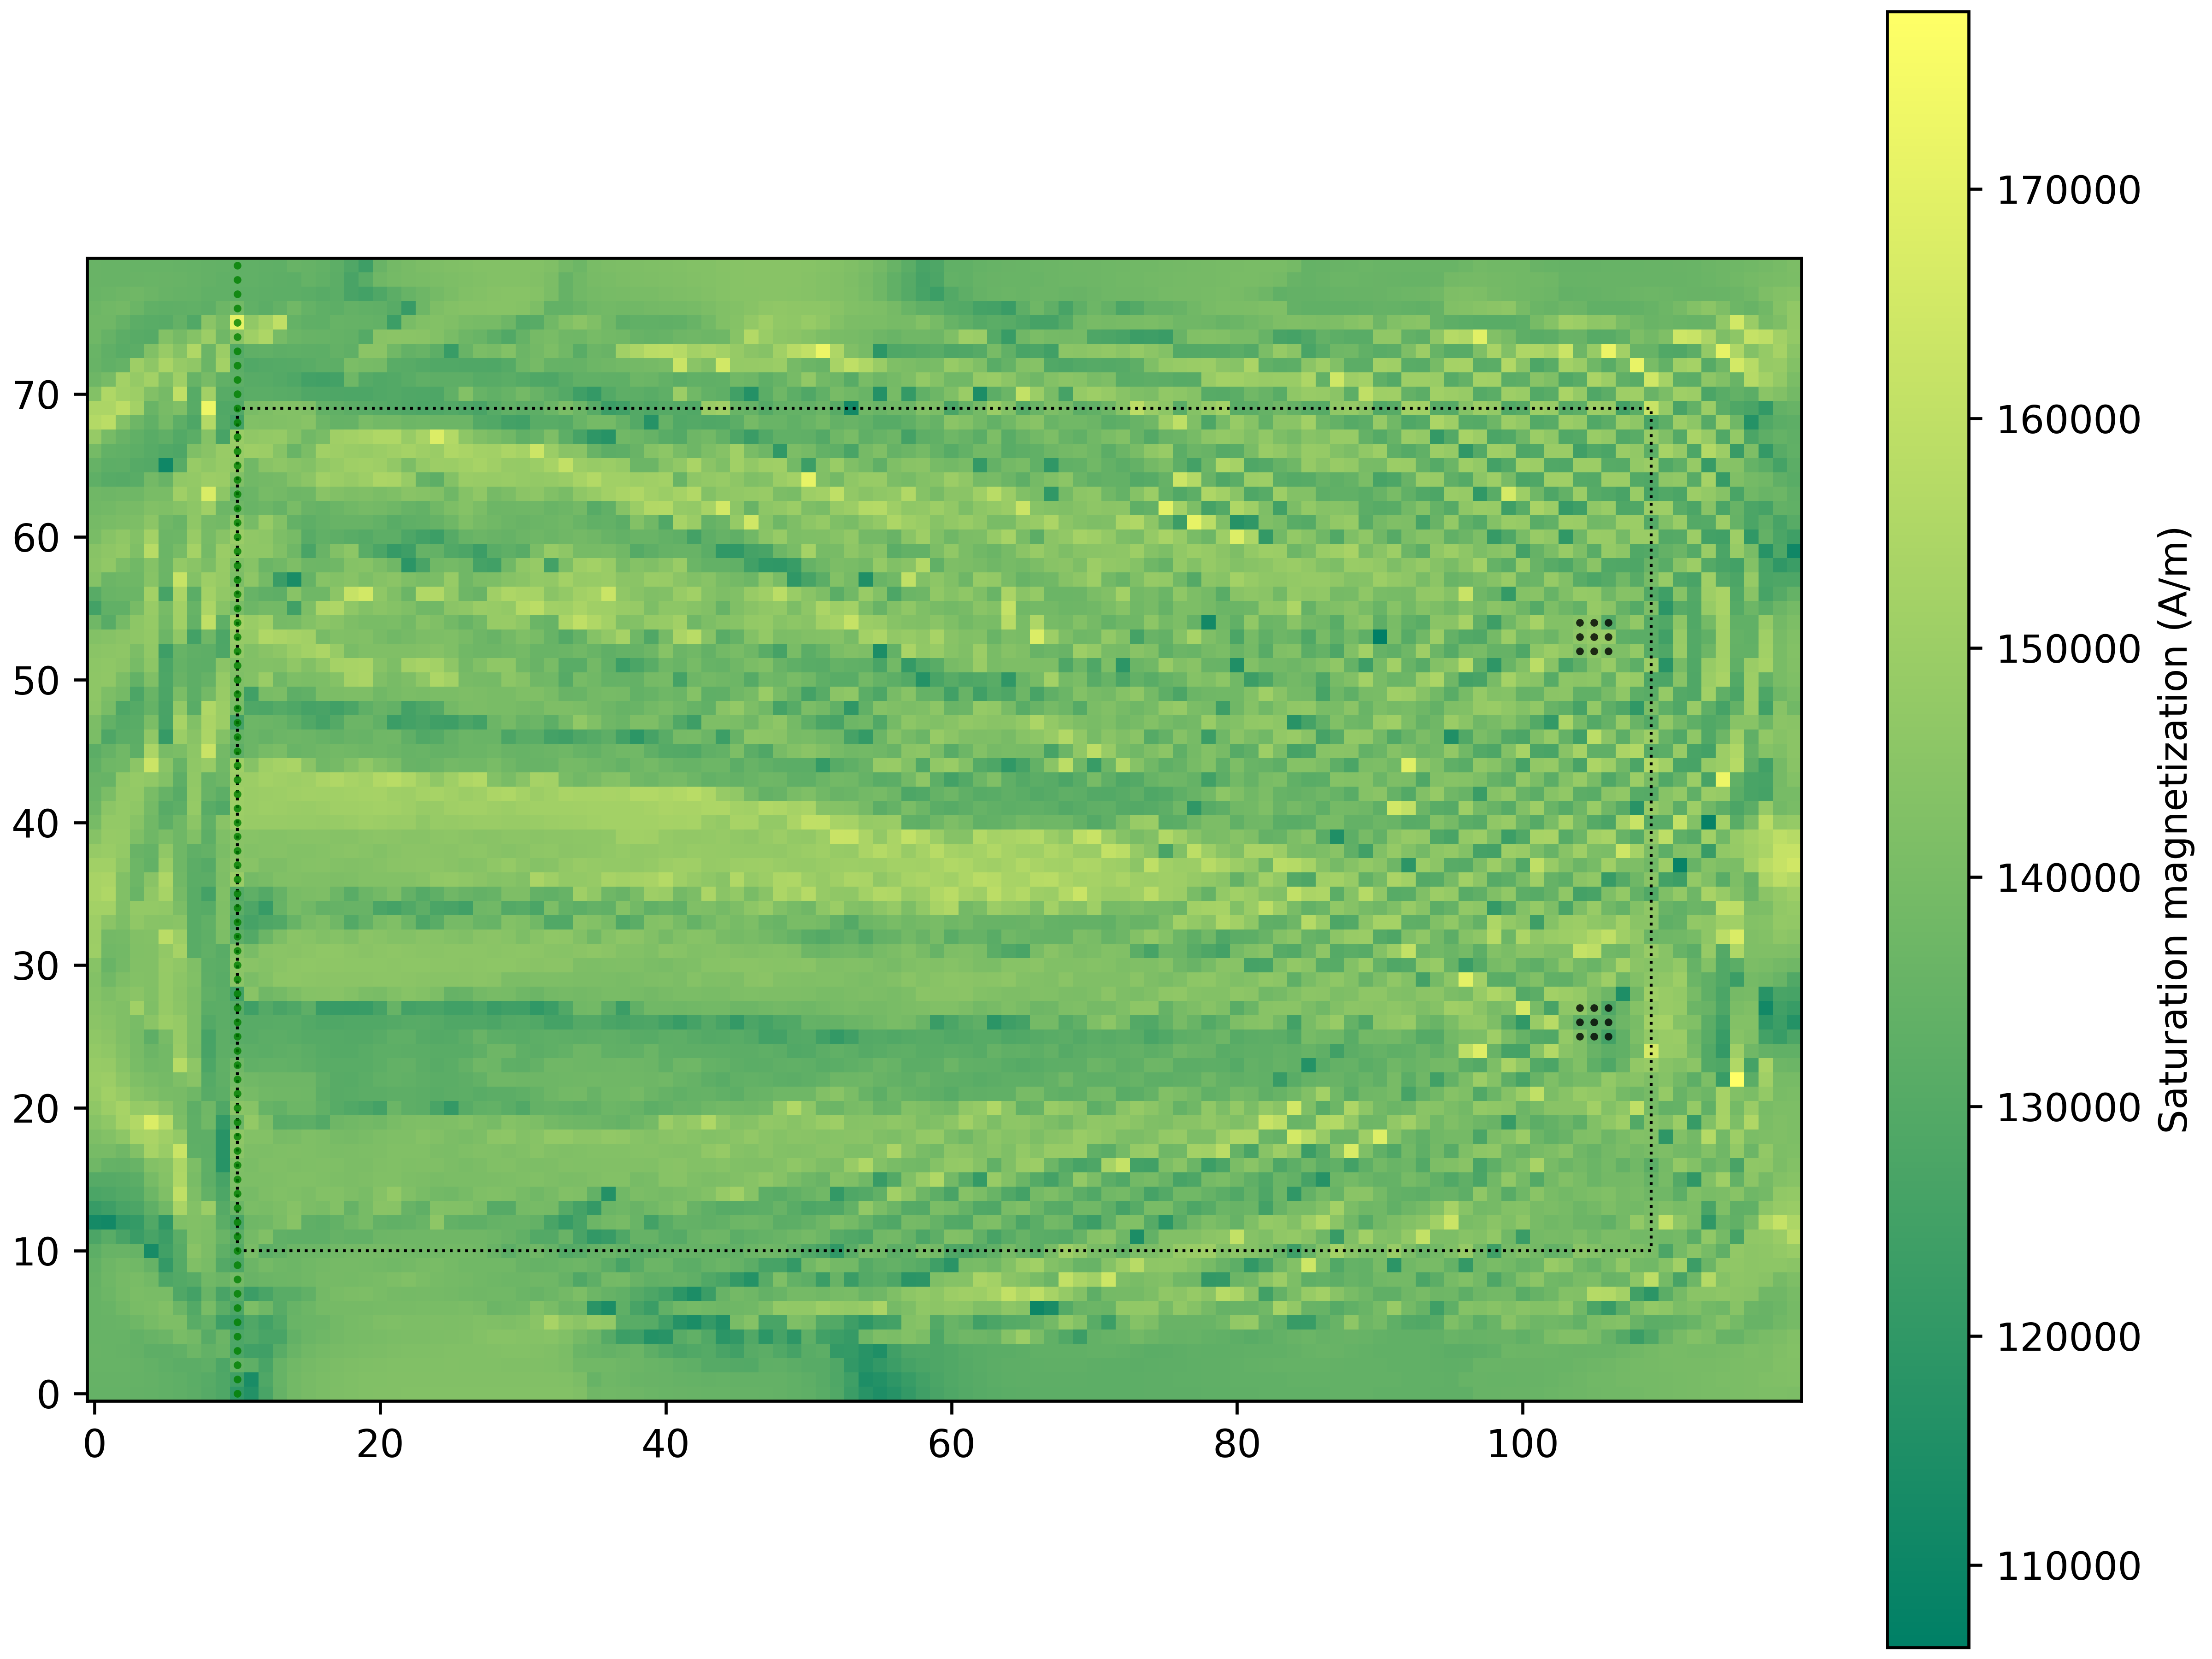

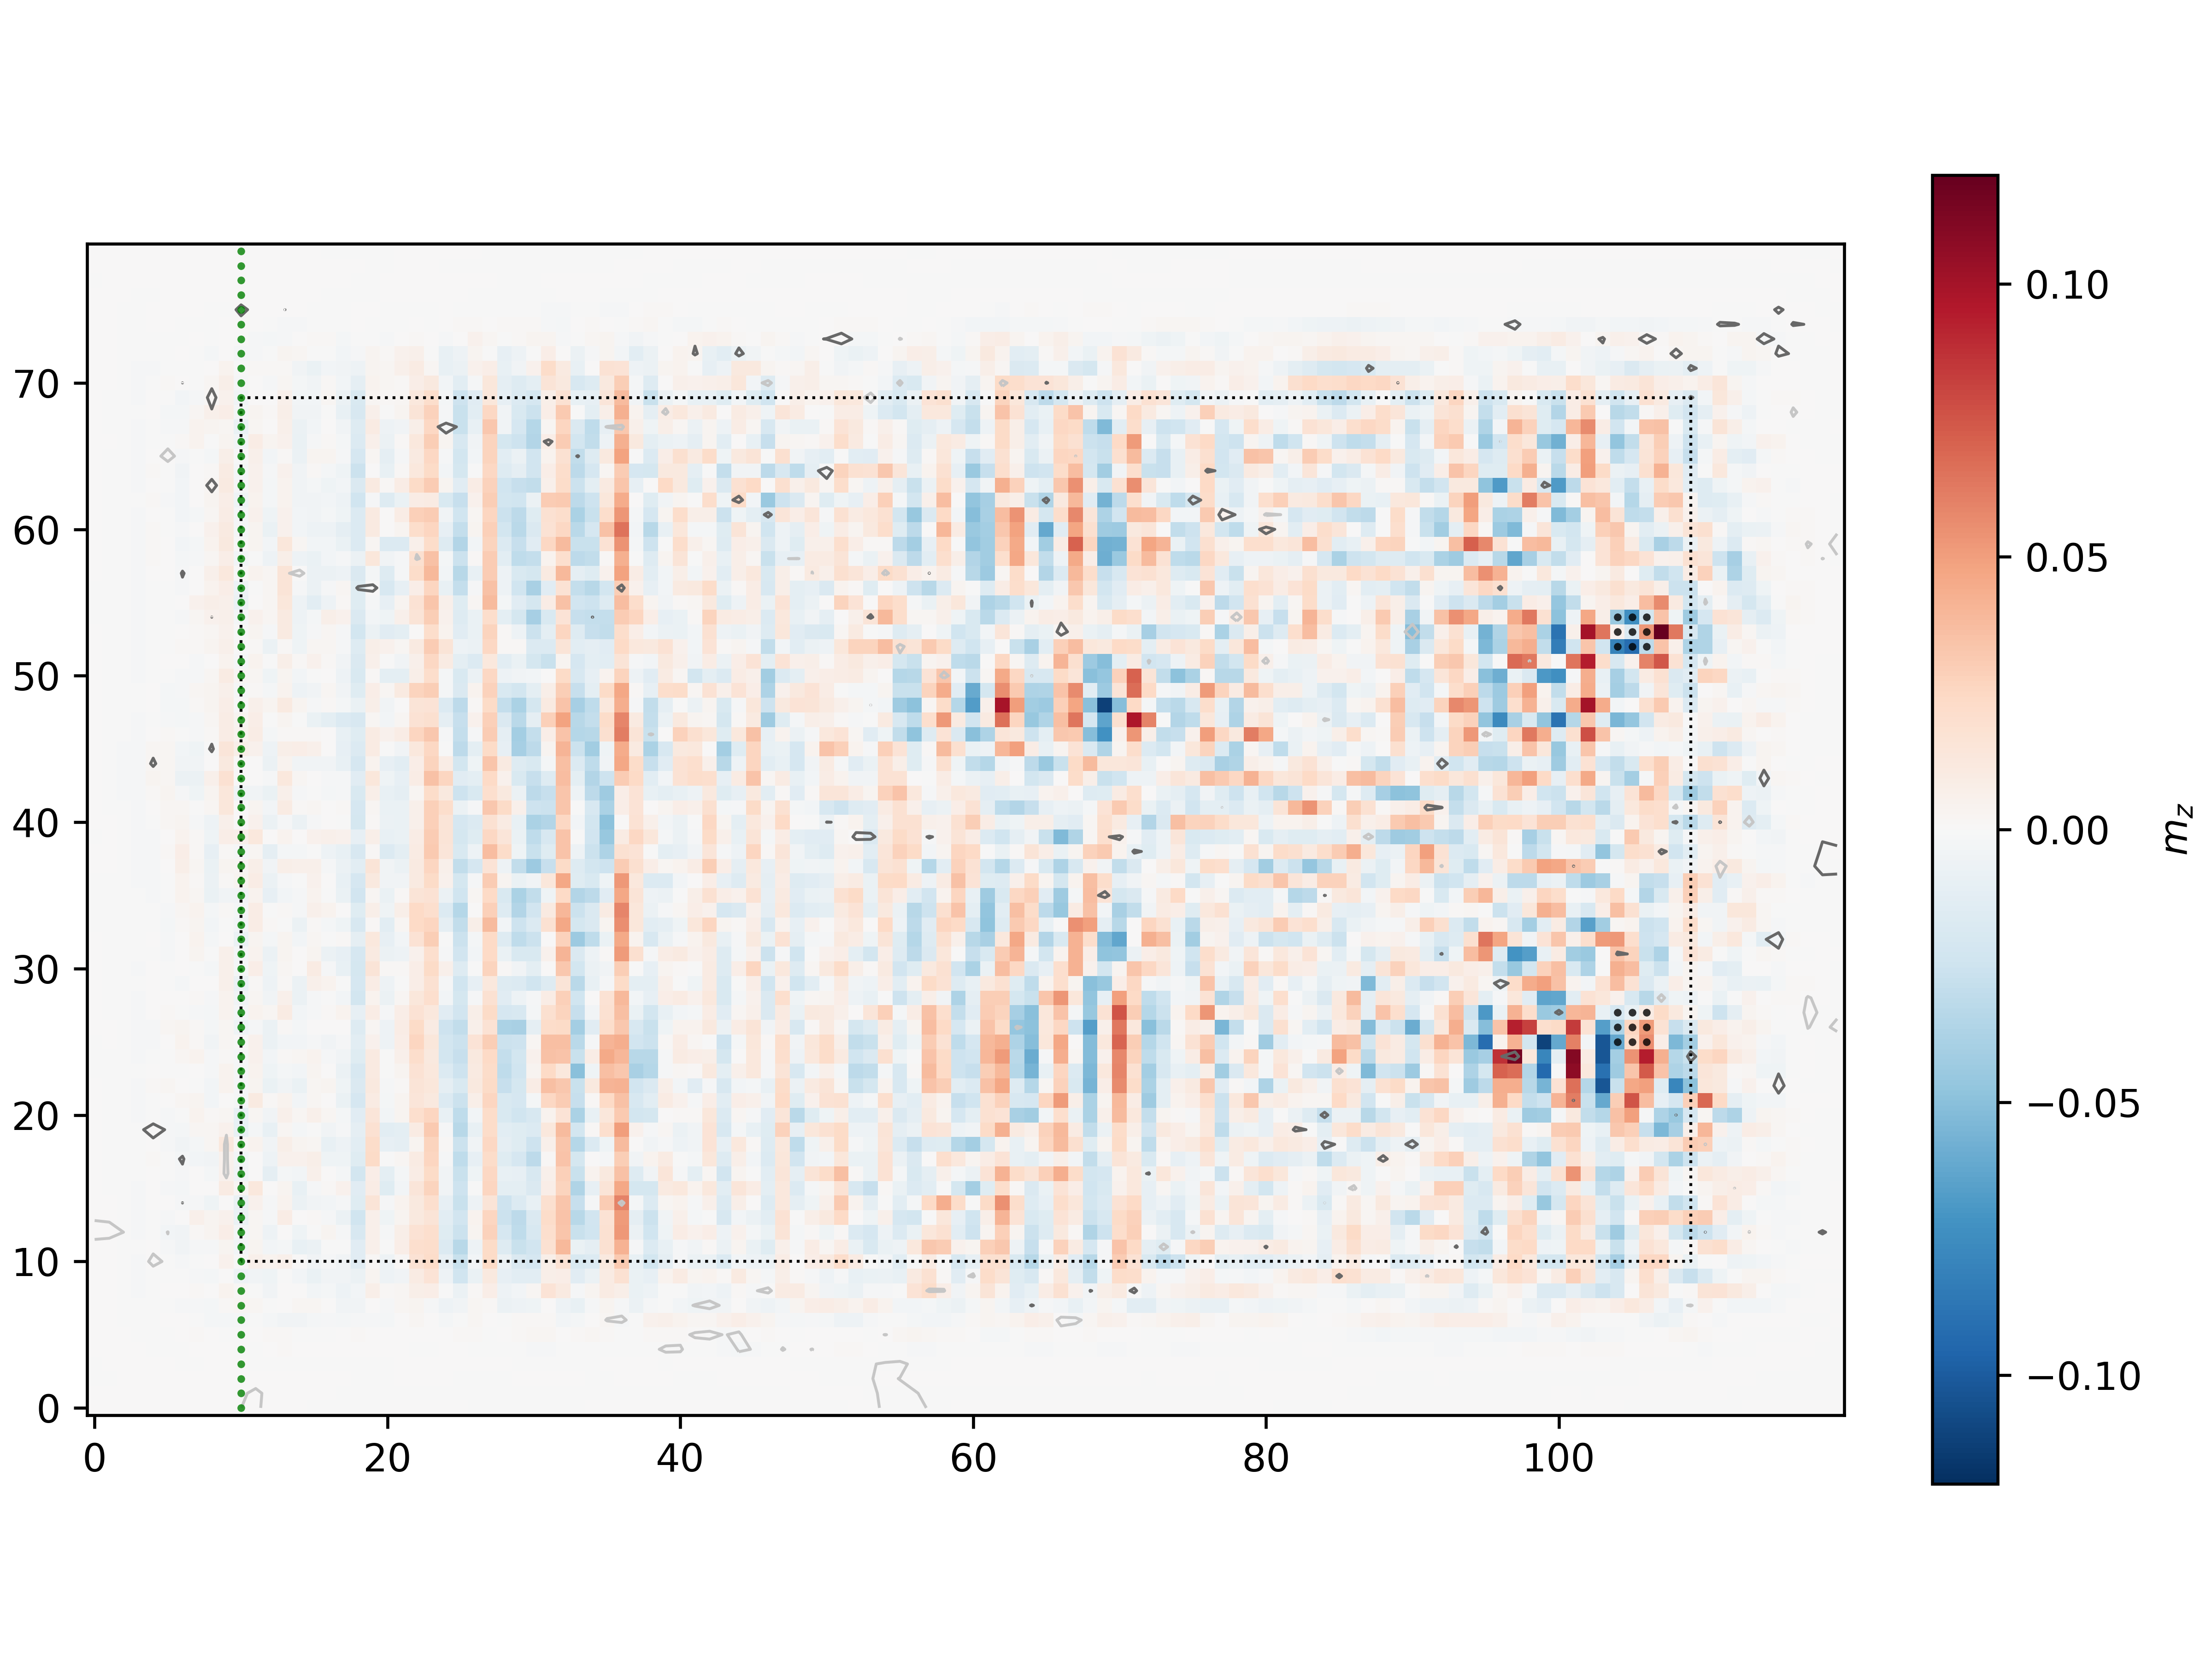

In [200]:
#@title ## 6. Preview the result
from IPython.display import Image, display
%cd 
%cd /content/Spintorch_packages/plots/focus_Ms
#@markdown plot which epoch results 
Full_Loss_plot  = True #@param {type:"boolean"}
epoch_no = "19" #@param {type:"string"}
X_value = "X0" #@param {type:"raw"}
output_epoch   = True #@param {type:"boolean"}
integrated_epoch = True #@param {type:"boolean"}
geometry_epoch  = True #@param {type:"boolean"}
snapshot_time = "1940" #@param {type:"string"}
time_snapshot  = False #@param {type:"boolean"}
display(Image("loss.png", width=600, height=300))
display(Image("output_epoch"+epoch_no+"_"+X_value+".png", width=300, height=300))
display(Image("integrated_epoch"+epoch_no+".png", width=800, height=500))
display(Image("geometry_epoch"+epoch_no+".png", width=800, height=500))
display(Image("snapshot_time"+snapshot_time+"_epoch"+epoch_no+".png", width=800, height=600))